In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/loan_data_new.csv')


# №1 Знакомство с датасетом

In [3]:
df.head()

,Age,Gender,Education,Person Income,Employee Experience,Home Onwership,Loan Amount,Loan Intent,Loan interest Rate,Loan percentage,Credit History,Credit Score,Previous Loan,Loan Status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [4]:
# Смотрим общую информацию, пропуски и статистику
print("\nРазмер данных:", df.shape, "\n")
df.info()
display(df.describe())


Размер данных: (45000, 14) 

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  45000 non-null  int64  
 1   Gender               45000 non-null  str    
 2   Education            45000 non-null  str    
 3   Person Income        45000 non-null  int64  
 4   Employee Experience  45000 non-null  int64  
 5   Home Onwership       45000 non-null  str    
 6   Loan Amount          45000 non-null  int64  
 7   Loan Intent          45000 non-null  str    
 8   Loan interest Rate   45000 non-null  float64
 9   Loan percentage      45000 non-null  float64
 10  Credit History       45000 non-null  int64  
 11  Credit Score         45000 non-null  int64  
 12  Previous Loan        45000 non-null  str    
 13  Loan Status          45000 non-null  int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 6.2 MB


,Age,Person Income,Employee Experience,Loan Amount,Loan interest Rate,Loan percentage,Credit History,Credit Score,Loan Status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [5]:
#Проверяем баланс классов
print("Количество по классам:")
print(df["Loan Status"].value_counts())

print("\nДоли:")
print((df["Loan Status"].value_counts(normalize=True) * 100).round(1))
#Отсюда виден дизбаланс классов, это значит что нам нужно будет это чинить

Количество по классам:
Loan Status
0    35000
1    10000
Name: count, dtype: int64

Доли:
Loan Status
0    77.8
1    22.2
Name: proportion, dtype: float64


In [6]:
#Все признаки в датасете
features = [c for c in df.columns if c != "Loan Status"]
print("Признаки:", features)
print("\nЧисло признаков:", len(features))

Признаки: ['Age', 'Gender', 'Education', 'Person Income', 'Employee Experience', 'Home Onwership', 'Loan Amount', 'Loan Intent', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score', 'Previous Loan']

Число признаков: 13


> ## **Выводы по первичному осмотру**:
> 1. **Объем**: 45 000 строк и 14 колонок.
> 2. **Пропуски**: В данных нет отсутствующих значений `(NaN)`.
> 3. **Аномалии**: В статистике `Age` максимальное значение — 144 года, а в `Employee Experience` — 125 лет.
> 4. **Решение**: В следующем этапе очистим данные.




# №2 Здоровье данных

In [7]:
print("полных дубликатов:", df.duplicated().sum())

полных дубликатов: 0


In [8]:
# разделим признаки на числовые и категориальные
numeric = df.select_dtypes(include=np.number).columns.tolist()
categorical = df.select_dtypes(exclude=np.number).columns.tolist()

# целевую убираем из признаков
target = "Loan Status"
numeric = [c for c in numeric if c != target]

print("\nЧисловые признаки:", numeric)
print("Категориальные:", categorical)
print("Целевая:", target)


Числовые признаки: ['Age', 'Person Income', 'Employee Experience', 'Loan Amount', 'Loan interest Rate', 'Loan percentage', 'Credit History', 'Credit Score']
Категориальные: ['Gender', 'Education', 'Home Onwership', 'Loan Intent', 'Previous Loan']
Целевая: Loan Status


In [34]:
import pandas as pd

def count_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

print("Выбросы по числовым признакам:")
for col in numeric:
    n_out = count_outliers_iqr(df[col])
    print(f"  {col}: {n_out} выбросов")


Выбросы по числовым признакам:
  Age: 2188 выбросов
  Person Income: 2218 выбросов
  Employee Experience: 1724 выбросов
  Loan Amount: 2348 выбросов
  Loan interest Rate: 124 выбросов
  Loan percentage: 744 выбросов
  Credit History: 1366 выбросов
  Credit Score: 467 выбросов


In [ ]:
#Фильтруем физически невозможные записи
clean_df = df[(df['Age'] <= 80) & (df['Employee Experience'] <= 60)].copy()

print(f"Было строк в исходном датасете: {len(df)}")
print(f"Стало строк после очистки аномалий: {len(clean_df)}")
print(f"Удалено реальных ошибок: {len(df) - len(clean_df)}")

Было строк в исходном датасете: 45000
Стало строк после очистки аномалий: 44990
Удалено реальных ошибок: 10


> **Вывод по анализу выбросов:**
> 1. **Аномалии:** Из 45 000 строк удалено всего 10 фейковых записей - `Age > 80` и `Employee Experience > 60`.
> 2. **Финансовые показатели:** Выбросы по IQR в `Person Income`, `Loan Amount`, `Credit History` и др. **сохранены полностью**, так как отражают реальное финансовое разнообразие клиентов.

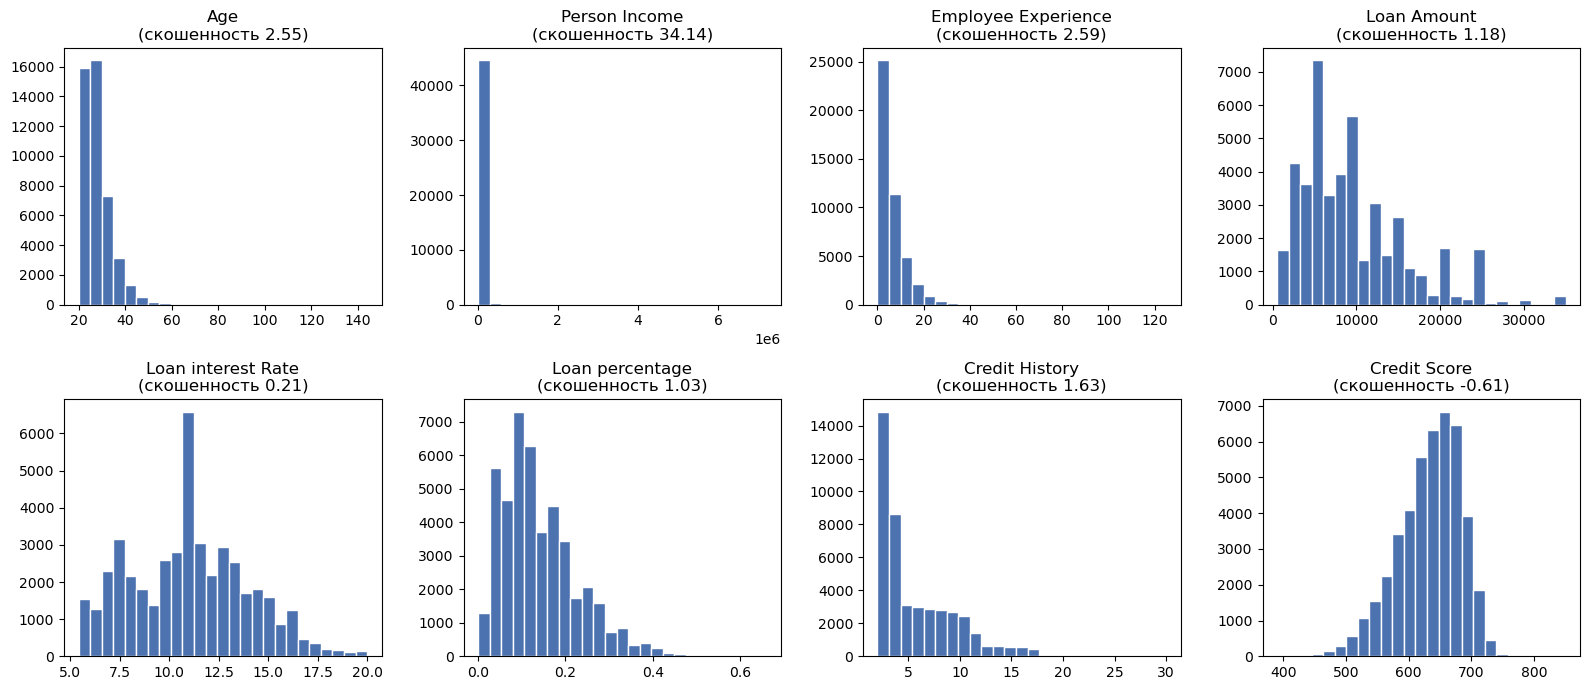

In [37]:
import matplotlib.pyplot as plt

# гистограммы всех числовых признаков
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col in zip(axes.flatten(), numeric):
    ax.hist(df[col].dropna(), bins=25, color="#4C72B0", edgecolor="white")
    ax.set_title(f"{col}\n(скошенность {df[col].skew():.2f})")

plt.tight_layout()
plt.show()



In [35]:
# частоты категориальных
print("Категориальные признаки:")
for col in categorical:
    print((df[col].value_counts(normalize=True) * 100).round(1))

Категориальные признаки:
Gender
male      55.2
female    44.8
Name: proportion, dtype: float64
Education
Bachelor       29.8
Associate      26.7
High School    26.6
Master         15.5
Doctorate       1.4
Name: proportion, dtype: float64
Home Onwership
RENT        52.1
MORTGAGE    41.1
OWN          6.6
OTHER        0.3
Name: proportion, dtype: float64
Loan Intent
EDUCATION            20.3
MEDICAL              19.0
VENTURE              17.4
PERSONAL             16.8
DEBTCONSOLIDATION    15.9
HOMEIMPROVEMENT      10.6
Name: proportion, dtype: float64
Previous Loan
Yes    50.8
No     49.2
Name: proportion, dtype: float64


In [31]:
print("skewness:")
for col in numeric:
    print(df[col].name, ": ", df[col].skew(), sep="")

skewness:
Age: 2.548154005038242
Person Income: 34.137583132969915
Employee Experience: 2.5949173726318264
Loan Amount: 1.1797312856279225
Loan interest Rate: 0.21378407238735642
Loan percentage: 1.0345121511827238
Credit History: 1.6317199538415361
Credit Score: -0.6102608322577945
